In [2]:
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import re
import scipy
from scipy.stats import norm, linregress, pearsonr
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1

import seaborn as sns
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, roc_curve, auc
from tqdm import tqdm 
pd.set_option('display.width', 1000)


### Load in the HTT data

In [ ]:
HTT = pd.read_csv('./real_participants/average_merged_tasks.csv', usecols = ['Participant_ID', 'HTT_average_score', 'HTT_mean_confidence'])

### Accuracy + Confidence

In [4]:
display(HTML(HTT.to_html()))

print(HTT['HTT_average_score'].describe())

HTT_feelers = HTT[HTT['HTT_average_score'] >0.8]
print('\nParticipants >0.8 [CHANCE]:',(len(HTT_feelers)/len(HTT['HTT_average_score']) * 100), '%; n = ',len(HTT_feelers))


,Participant_ID,HTT_average_score,HTT_mean_confidence
0,4,0.421667,57.500000
1,5,0.570000,30.000000
2,6,0.616667,51.666667
3,7,0.351667,42.500000
4,8,0.635000,48.333333
5,11,0.968333,65.833333
6,19,0.273333,22.500000
7,24,0.116667,45.833333
8,28,-0.125000,65.000000
9,30,0.410000,15.333333


count    40.000000
mean      0.466208
std       0.341095
min      -0.493333
25%       0.305833
50%       0.531667
75%       0.699167
max       0.968333
Name: HTT_average_score, dtype: float64

Participants >0.8 [CHANCE]: 19.51219512195122 %; n =  8


S_HDT: Is confidence related to accuracy on task? 
 R = 0.29334439539013246 
 P-value: 0.06619646268383038 
 R2 =  0.08605093430680237


<Figure size 1000x600 with 0 Axes>

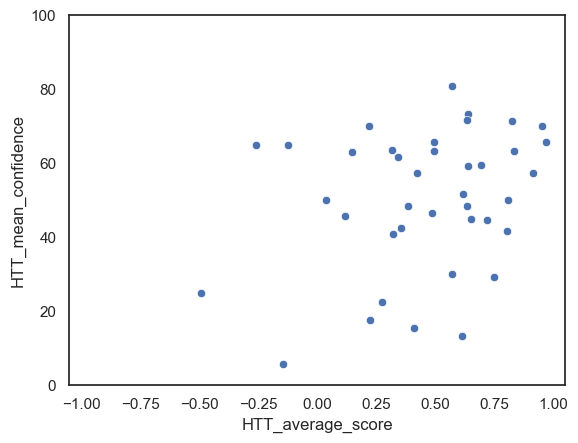

In [5]:
# Set plot style
sns.set(style="white")

# Create scatter plot 1
plt.figure(figsize=(10, 6))
norm = plt.Normalize(0, 1)
cbar_ticks = np.arange(0, 1.1, 0.1) 
fig, ax = plt.subplots()
scatter = sns.scatterplot(
    data=HTT, 
    y='HTT_mean_confidence', 
    x='HTT_average_score',
    alpha=1.0               
)
plt.xlim(-1.05,1.05)
plt.ylim(0,100)  


HTT = HTT.dropna(subset=['HTT_average_score', 'HTT_mean_confidence'])

HTT_pearsonR_conf_accuracy = pearsonr(HTT['HTT_average_score'], HTT['HTT_mean_confidence'])
print('S_HDT: Is confidence related to accuracy on task? \n R =', HTT_pearsonR_conf_accuracy[0], '\n P-value:',HTT_pearsonR_conf_accuracy[1], '\n R2 = ', HTT_pearsonR_conf_accuracy[0]**2 )